<a href="https://colab.research.google.com/github/vinothini20506258-oss/Heart_Disease_Prediction/blob/main/AIML_CT_PROJECT_07_07_26_VINOTHINI_CSE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**HEART** **DISEASE** **PREDICTION**

In [341]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix, classification_report, roc_auc_score, roc_curve

1.Load Data

2.Import Libraries

In [342]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [343]:
df = pd.read_csv("cleveland_raw.csv")
df.head()

,63.0,1.0,1.0.1,145.0,233.0,1.0.2,2.0,150.0,0.0,2.3,3.0,0.0.1,6.0,0
0,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
1,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
2,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
3,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
4,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0


In [344]:
columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs",
    "restecg", "thalach", "exang", "oldpeak",
    "slope", "ca", "thal", "target"
]

df = pd.read_csv(
    "processed.hungarian.data",
    sep=r"\s+",
    header=None,
    names=columns,
    na_values="?"
)

In [345]:
cols = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
        'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

df = pd.read_csv('cleveland_raw.csv', names=cols, na_values='?')

print("Shape:", df.shape)
print(df.head())
print(df.info())



Shape: (303, 14)
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       2  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 

3. Clean the data

In [346]:
# ca and thal have a few missing values -> fill with the most frequent value (mode)
df['ca'] = df['ca'].fillna(df['ca'].mode()[0])
df['thal'] = df['thal'].fillna(df['thal'].mode()[0])

# Convert target to binary: 0 = no disease, 1 = disease present (was 1,2,3,4)
df['target'] = (df['target'] > 0).astype(int)

print("\nBinary target distribution:")
print(df['target'].value_counts())


Binary target distribution:
target
0    164
1    139
Name: count, dtype: int64


4.EDA

In [347]:
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df)
plt.title('Heart Disease Distribution (0 = No, 1 = Yes)')
plt.savefig('eda_target_distribution.png', dpi=100, bbox_inches='tight')
plt.close()

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.savefig('eda_correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.close()

print("\nSaved EDA plots: eda_target_distribution.png, eda_correlation_heatmap.png")


Saved EDA plots: eda_target_distribution.png, eda_correlation_heatmap.png


5.Split Features & Target




In [348]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features (helps Logistic Regression and KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

6.Train models

In [349]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42)
}

results = {}

for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    results[name] = {
        'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'auc': auc
    }

    print(f"\n=== {name} ===")
    print(f"Accuracy:  {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall:    {rec:.3f}  <-- most important: catches actual disease cases")
    print(f"F1 Score:  {f1:.3f}")
    print(f"ROC-AUC:   {auc:.3f}")
    print(classification_report(y_test, y_pred))


=== Logistic Regression ===
Accuracy:  0.869
Precision: 0.812
Recall:    0.929  <-- most important: catches actual disease cases
F1 Score:  0.867
ROC-AUC:   0.951
              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61


=== Random Forest ===
Accuracy:  0.902
Precision: 0.844
Recall:    0.964  <-- most important: catches actual disease cases
F1 Score:  0.900
ROC-AUC:   0.955
              precision    recall  f1-score   support

           0       0.97      0.85      0.90        33
           1       0.84      0.96      0.90        28

    accuracy                           0.90        61
   macro avg       0.90      0.91      0.90        61
weighted avg       0.91      0.90      0.90        61



7.Compare Result

In [350]:
results_df = pd.DataFrame(results).T
print("\n=== Model Comparison ===")
print(results_df)
results_df.to_csv('model_comparison.csv')


=== Model Comparison ===
                     accuracy  precision    recall        f1       auc
Logistic Regression  0.868852    0.81250  0.928571  0.866667  0.951299
Random Forest        0.901639    0.84375  0.964286  0.900000  0.954545


8.Important features(Random Forest)

In [351]:
rf_model = models['Random Forest']
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
importances.plot(kind='barh')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.savefig('feature_importance.png', dpi=100, bbox_inches='tight')
plt.close()

print("\nSaved feature_importance.png")
print("\nDone. Files saved: eda_target_distribution.png, eda_correlation_heatmap.png, feature_importance.png, model_comparison.csv")


Saved feature_importance.png

Done. Files saved: eda_target_distribution.png, eda_correlation_heatmap.png, feature_importance.png, model_comparison.csv


Loading three dataset

In [352]:
import pandas as pd

columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs",
    "restecg", "thalach", "exang", "oldpeak",
    "slope", "ca", "thal", "target"
]

hungarian = pd.read_csv(
    "processed.hungarian.data",
    sep=",", # Changed from r"\s+"
    header=None,
    names=columns,
    na_values="?"
)

switzerland = pd.read_csv(
    "processed.switzerland.data",
    sep=",", # Changed from r"\s+"
    header=None,
    names=columns,
    na_values="?"
)

va = pd.read_csv(
    "processed.va.data",
    sep=",", # Changed from r"\s+"
    header=None,
    names=columns,
    na_values="?"
)

In [353]:
print(hungarian.shape)
print(switzerland.shape)
print(va.shape)

(294, 14)
(123, 14)
(200, 14)


Merge dataset

In [354]:
merged = pd.concat([hungarian, switzerland, va], ignore_index=True)

print(merged.shape)

merged.to_csv("heart_disease_merged.csv", index=False)


(617, 14)


In [355]:
# Display all rows and columns
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

print(merged)

     age  sex  cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0     28    1   2     130.0  132.0  0.0      2.0    185.0    0.0      0.0   
1     29    1   2     120.0  243.0  0.0      0.0    160.0    0.0      0.0   
2     29    1   2     140.0    NaN  0.0      0.0    170.0    0.0      0.0   
3     30    0   1     170.0  237.0  0.0      1.0    170.0    0.0      0.0   
4     31    0   2     100.0  219.0  0.0      1.0    150.0    0.0      0.0   
5     32    0   2     105.0  198.0  0.0      0.0    165.0    0.0      0.0   
6     32    1   2     110.0  225.0  0.0      0.0    184.0    0.0      0.0   
7     32    1   2     125.0  254.0  0.0      0.0    155.0    0.0      0.0   
8     33    1   3     120.0  298.0  0.0      0.0    185.0    0.0      0.0   
9     34    0   2     130.0  161.0  0.0      0.0    190.0    0.0      0.0   
10    34    1   2     150.0  214.0  0.0      1.0    168.0    0.0      0.0   
11    34    1   2      98.0  220.0  0.0      0.0    150.0    0.0      0.0   

**01_Data_Preprocessing**

Import Libraries

Define Column Names

Load the Dataset

Add Dataset Source

Merge

Check Dataset

Save the Dataset

Basic Information

Summary Statistics

Count Missing Values

In [356]:
#Import Libraries

In [357]:
#Define Column Names
columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs",
    "restecg", "thalach", "exang", "oldpeak",
    "slope", "ca", "thal", "target" ]

In [358]:
#Load the Datasets
cleveland = pd.read_csv(
    "cleveland_raw.csv",
    sep=",",
    header=None,
    names=columns,
    na_values="?"
)

hungarian = pd.read_csv(
    "processed.hungarian.data",
    sep=r"\s+",
    header=None,
    names=columns,
    na_values="?"
)

switzerland = pd.read_csv(
    "processed.switzerland.data",
    sep=r"\s+",
    header=None,
    names=columns,
    na_values="?"
)

In [359]:
#Add Dataset Source
cleveland["dataset"] = "Cleveland"
hungarian["dataset"] = "Hungarian"
switzerland["dataset"] = "Switzerland"
va["dataset"] = "VA"

In [360]:
#Merge
heart = pd.concat(
    [cleveland, hungarian, switzerland, va],
    ignore_index=True
)

In [361]:
#Check Dataset
print("Shape:", heart.shape)

heart.head()

Shape: (920, 15)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,dataset
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0.0,Cleveland
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2.0,Cleveland
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1.0,Cleveland
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0.0,Cleveland
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0.0,Cleveland


In [362]:
#Save the Dataset
heart.to_csv("merged_heart_disease.csv", index=False)

In [363]:
#Basic Information
heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    object 
 1   sex       503 non-null    float64
 2   cp        503 non-null    float64
 3   trestbps  447 non-null    float64
 4   chol      496 non-null    float64
 5   fbs       496 non-null    float64
 6   restecg   503 non-null    float64
 7   thalach   450 non-null    float64
 8   exang     450 non-null    float64
 9   oldpeak   447 non-null    float64
 10  slope     401 non-null    float64
 11  ca        301 non-null    float64
 12  thal      335 non-null    float64
 13  target    503 non-null    float64
 14  dataset   920 non-null    object 
dtypes: float64(13), object(2)
memory usage: 107.9+ KB


In [364]:
#Summary Statistics
heart.describe()

,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,503.000000,503.000000,447.000000,496.000000,496.000000,503.000000,450.000000,450.000000,447.000000,401.000000,301.000000,335.000000,503.000000
mean,0.795229,3.296223,132.357942,220.254032,0.227823,0.888668,140.848889,0.431111,1.130201,1.730673,0.667774,4.892537,1.168986
std,0.403936,0.913448,18.958222,88.199911,0.419851,0.892382,25.839134,0.495783,1.150007,0.668791,0.935908,1.940840,1.256565
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,69.000000,0.000000,-0.500000,1.000000,0.000000,3.000000,0.000000
25%,1.000000,3.000000,120.000000,199.750000,0.000000,0.000000,120.250000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,1.000000,4.000000,130.000000,231.500000,0.000000,1.000000,143.000000,0.000000,1.000000,2.000000,0.000000,3.000000,1.000000
75%,1.000000,4.000000,141.000000,270.000000,0.000000,2.000000,161.000000,1.000000,1.900000,2.000000,1.000000,7.000000,2.000000
max,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


In [365]:
#Count Missing Values
heart.isnull().sum()

,0
age,0
sex,417
cp,417
trestbps,473
chol,424
fbs,424
restecg,417
thalach,470
exang,470
oldpeak,473


Data Cleaning

heck the dataset shape

Check data types

Count missing values

Check duplicates

Check unique values in the target column

Fill missing values Numerical columns

Confirm all missing values are handled

Save the cleaned dataset

In [366]:
#Check the dataset shape
print("Rows and Columns:", heart.shape)

Rows and Columns: (920, 15)


In [367]:
#Check data types
heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    object 
 1   sex       503 non-null    float64
 2   cp        503 non-null    float64
 3   trestbps  447 non-null    float64
 4   chol      496 non-null    float64
 5   fbs       496 non-null    float64
 6   restecg   503 non-null    float64
 7   thalach   450 non-null    float64
 8   exang     450 non-null    float64
 9   oldpeak   447 non-null    float64
 10  slope     401 non-null    float64
 11  ca        301 non-null    float64
 12  thal      335 non-null    float64
 13  target    503 non-null    float64
 14  dataset   920 non-null    object 
dtypes: float64(13), object(2)
memory usage: 107.9+ KB


In [368]:
#Count missing values
heart.isnull().sum()

,0
age,0
sex,417
cp,417
trestbps,473
chol,424
fbs,424
restecg,417
thalach,470
exang,470
oldpeak,473


In [369]:
#Check duplicates
print("Duplicate rows:", heart.duplicated().sum())

Duplicate rows: 2


In [370]:
#If duplicates exist:
heart.drop_duplicates(inplace=True)

In [371]:
#Check unique values in the target column
heart["target"].value_counts()

,count
target,
0.0,215
1.0,111
3.0,77
2.0,76
4.0,23


In [372]:
#Convert it to a binary target:
heart["target"] = heart["target"].apply(lambda x: 0 if x == 0 else 1)

In [373]:
#Verify the result:
heart["target"].value_counts()

,count
target,
1,703
0,215


In [374]:
import pandas as pd

#Fill missing values
num_cols = [
    "age", "trestbps", "chol",
    "thalach", "oldpeak"
]

# Convert 'age' column to numeric, coercing errors to NaN
heart["age"] = pd.to_numeric(heart["age"], errors="coerce")

for col in num_cols:
    heart[col] = heart[col].fillna(heart[col].median())

In [375]:
#Categorical columns
cat_cols = [
    "sex", "cp", "fbs", "restecg",
    "exang", "slope", "ca", "thal"
]

for col in cat_cols:
    heart[col] = heart[col].fillna(heart[col].mode()[0])


In [376]:
#Confirm all missing values are handled
heart.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [377]:
#Save the cleaned dataset
heart.to_csv("heart_disease_cleaned.csv", index=False)

Exploratory Data Analysis

Load the cleaned dataset

Dataset Overview

Statistical Summary

Target Distribution

Age Distribution

Gender Distribution

Correlation Matrix

Boxplot (Outlier Detection)

Pairplot (Optional)

Disease by Age

Disease by Cholesterol

Save EDA Insights

In [378]:
#Load the cleaned dataset
heart = pd.read_csv("heart_disease_cleaned.csv")

heart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,dataset
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,Cleveland
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1,Cleveland
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,Cleveland
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,Cleveland
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,Cleveland


In [379]:
#Dataset Overview
print("Shape:", heart.shape)
print()

heart.info()

Shape: (918, 15)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       918 non-null    float64
 1   sex       918 non-null    float64
 2   cp        918 non-null    float64
 3   trestbps  918 non-null    float64
 4   chol      918 non-null    float64
 5   fbs       918 non-null    float64
 6   restecg   918 non-null    float64
 7   thalach   918 non-null    float64
 8   exang     918 non-null    float64
 9   oldpeak   918 non-null    float64
 10  slope     918 non-null    float64
 11  ca        918 non-null    float64
 12  thal      918 non-null    float64
 13  target    918 non-null    int64  
 14  dataset   918 non-null    object 
dtypes: float64(13), int64(1), object(1)
memory usage: 107.7+ KB


In [380]:
#Statistical Summary
heart.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,56.665577,0.887800,3.615468,131.126362,225.667756,0.123094,0.485839,141.972767,0.210240,1.064488,1.882353,0.218954,3.690632,0.765795
std,6.588408,0.315785,0.761148,13.259401,65.065772,0.328724,0.794828,18.095479,0.407701,0.803891,0.461487,0.620436,1.484246,0.423732
min,29.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,69.000000,0.000000,-0.500000,1.000000,0.000000,3.000000,0.000000
25%,57.000000,1.000000,4.000000,130.000000,226.250000,0.000000,0.000000,143.000000,0.000000,1.000000,2.000000,0.000000,3.000000,1.000000
50%,57.000000,1.000000,4.000000,130.000000,232.000000,0.000000,0.000000,143.000000,0.000000,1.000000,2.000000,0.000000,3.000000,1.000000
75%,58.000000,1.000000,4.000000,130.000000,236.000000,0.000000,1.000000,143.000000,0.000000,1.000000,2.000000,0.000000,3.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


In [381]:
#Target Distribution
#This shows how many patients have heart disease.
heart["target"].value_counts()

,count
target,
1,703
0,215


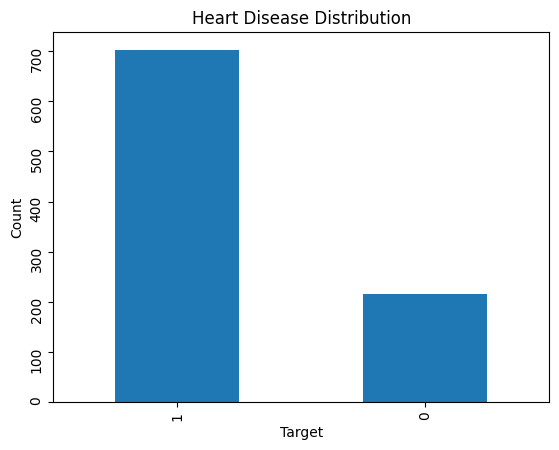

In [382]:
#Plot it:
heart["target"].value_counts().plot(kind="bar")

plt.title("Heart Disease Distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.yticks(rotation=90)

plt.show()

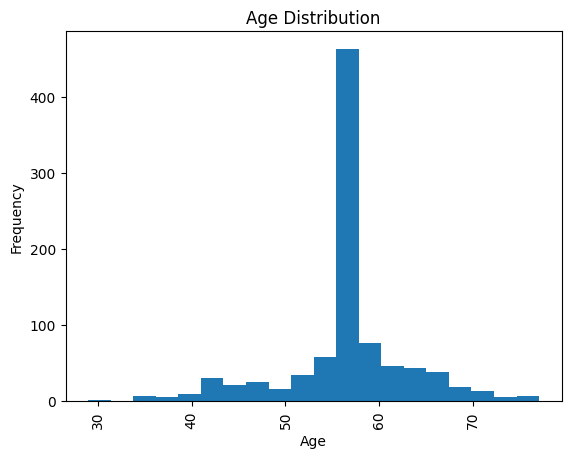

In [383]:
#Age Distribution
plt.hist(heart["age"], bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.xticks(rotation=90)

plt.show()

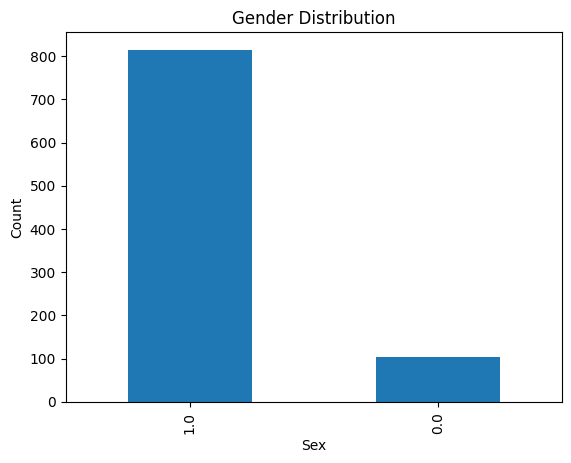

In [384]:
#Gender Distribution
heart["sex"].value_counts().plot(kind="bar")

plt.title("Gender Distribution")
plt.xlabel("Sex")
plt.ylabel("Count")

plt.show()

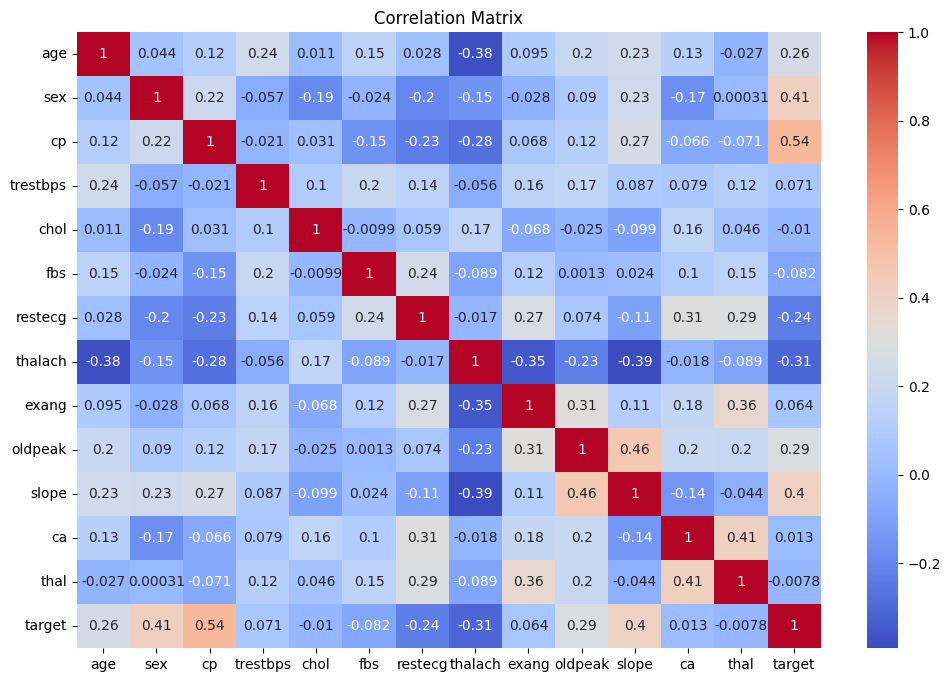

In [385]:
#Correlation Matrix
corr = heart.corr(numeric_only=True)

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

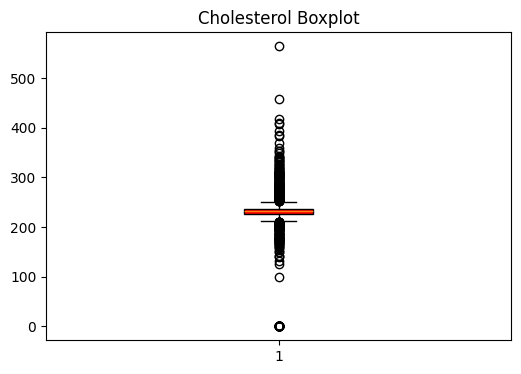

In [386]:
#Boxplot (Outlier Detection)
plt.figure(figsize=(6,4))

plt.boxplot(heart["chol"], patch_artist=True, boxprops=dict(facecolor='red'))

plt.title("Cholesterol Boxplot")

plt.show()

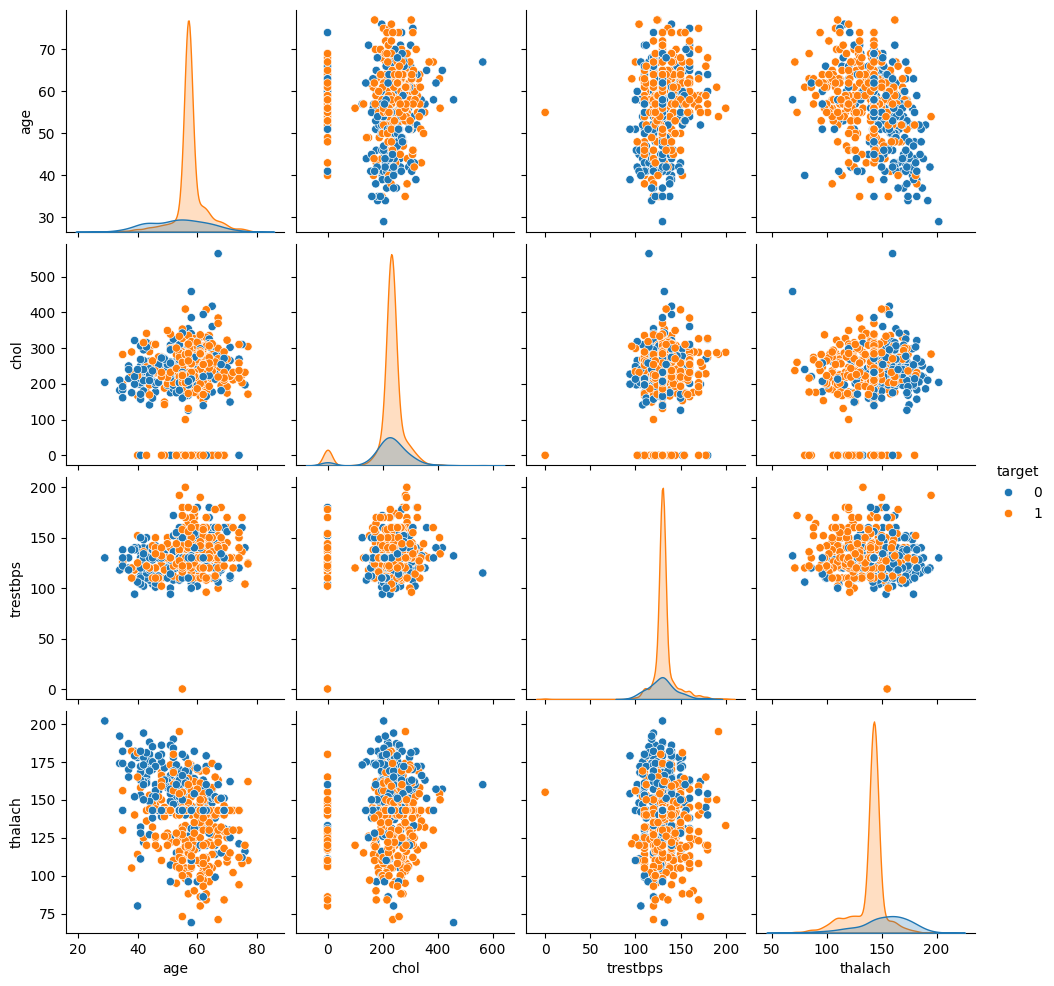

In [387]:
#Pairplot (Optional)
sns.pairplot(
    heart[
        [
            "age",
            "chol",
            "trestbps",
            "thalach",
            "target"
        ]
    ],
    hue="target"
)

plt.show()

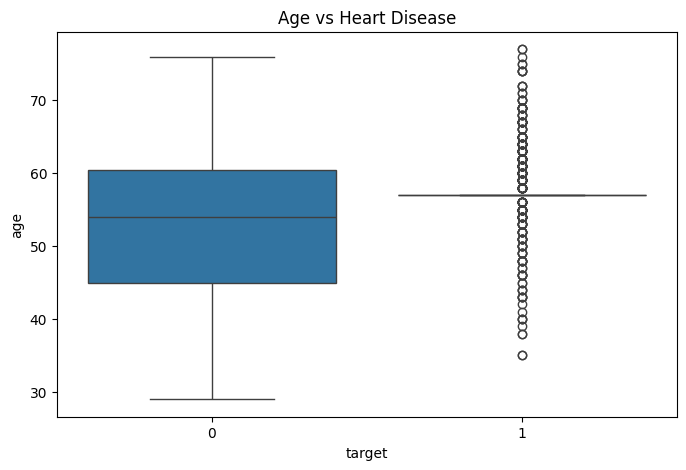

In [388]:
#Disease by Age
plt.figure(figsize=(8,5))

sns.boxplot(
    x="target",
    y="age",
    data=heart
)

plt.title("Age vs Heart Disease")

plt.show()

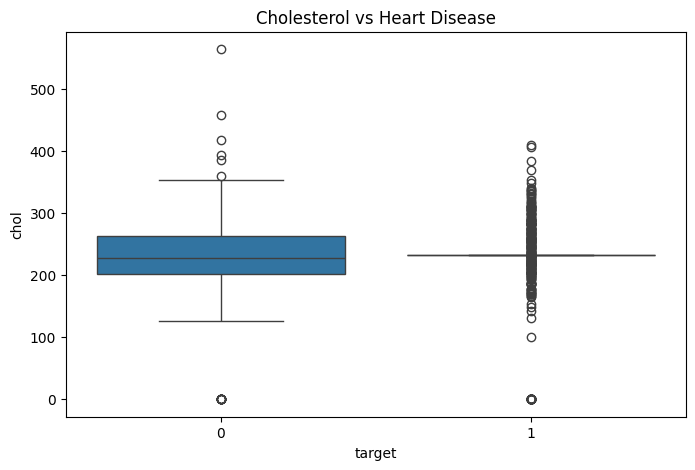

In [389]:
#Disease by Cholesterol
plt.figure(figsize=(8,5))

sns.boxplot(
    x="target",
    y="chol",
    data=heart
)

plt.title("Cholesterol vs Heart Disease")

plt.show()

Feature Engineering

Load the cleaned dataset

Create Age Groups

Cholesterol Category

Blood Pressure Category

Interaction Features

Heart Rate Ratio

Verify New Features

Check for Missing Values

Save the Feature-Engineered Dataset



In [390]:
heart = pd.read_csv("heart_disease_cleaned.csv")

heart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,dataset
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,Cleveland
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1,Cleveland
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,Cleveland
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,Cleveland
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,Cleveland


In [391]:
#Create Age Groups
#Age is Continous. Grouping it into range may help some models and also makes it easier to interpret.
heart["Age_Group"] = pd.cut(
    heart["age"],
    bins=[0, 30, 40, 50, 60, 70, 80],
    labels=["18-30", "31-40", "41-50", "51-60", "61-70", "71-80"]
)

heart["Age_Group"].value_counts()

,count
Age_Group,
51-60,631
61-70,151
41-50,92
31-40,22
71-80,21
18-30,1


In [392]:
#Cholesterol Category
'''Clinical reference values:

Normal: < 200
Borderline: 200–239
High: ≥ 240'''
heart["Chol_Category"] = pd.cut(
    heart["chol"],
    bins=[0, 199, 239, 700],
    labels=[
        "Normal",
        "Borderline",
        "High"
    ]
)
heart["Chol_Category"].value_counts()

,count
Chol_Category,
Borderline,575
High,219
Normal,75


In [393]:
#Blood Pressure Category
#Using resting blood pressure:
heart["BP_Category"] = pd.cut(
    heart["trestbps"],
    bins=[0, 120, 129, 139, 300],
    labels=[
        "Normal",
        "Elevated",
        "Stage1",
        "Stage2"
    ]
)
heart["BP_Category"].value_counts()

,count
BP_Category,
Stage1,571
Stage2,153
Normal,134
Elevated,59


In [394]:
#Interaction Features
'''These combine two existing variables.'''

#Age × Cholesterol'''
heart["Age_Chol"] = heart["age"] * heart["chol"]
#'''Age × Blood Pressure'''
heart["Age_BP"] = heart["age"] * heart["trestbps"]
#Cholesterol × Blood Pressure
heart["Chol_BP"] = heart["chol"] * heart["trestbps"]

In [395]:
#Heart Rate Ratio
heart["HeartRate_Age"] = heart["thalach"] / heart["age"]

In [396]:
#Verify New Features
heart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,dataset,Age_Group,Chol_Category,BP_Category,Age_Chol,Age_BP,Chol_BP,HeartRate_Age
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,Cleveland,61-70,Borderline,Stage2,14679.0,9135.0,33785.0,2.380952
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1,Cleveland,61-70,High,Stage2,19162.0,10720.0,45760.0,1.611940
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,Cleveland,61-70,Borderline,Normal,15343.0,8040.0,27480.0,1.925373
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,Cleveland,31-40,High,Stage1,9250.0,4810.0,32500.0,5.054054
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,Cleveland,41-50,Borderline,Stage1,8364.0,5330.0,26520.0,4.195122


In [397]:
#Check for Missing Values
heart.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [398]:
#Save the Feature-Engineered Dataset
heart.to_csv("heart_disease_feature_engineered.csv", index=False)

In [399]:
heart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,dataset,Age_Group,Chol_Category,BP_Category,Age_Chol,Age_BP,Chol_BP,HeartRate_Age
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,Cleveland,61-70,Borderline,Stage2,14679.0,9135.0,33785.0,2.380952
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1,Cleveland,61-70,High,Stage2,19162.0,10720.0,45760.0,1.611940
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,Cleveland,61-70,Borderline,Normal,15343.0,8040.0,27480.0,1.925373
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,Cleveland,31-40,High,Stage1,9250.0,4810.0,32500.0,5.054054
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,Cleveland,41-50,Borderline,Stage1,8364.0,5330.0,26520.0,4.195122


In [400]:
print(heart.shape)

(918, 22)


In [401]:
heart.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [402]:
print(heart["dataset"].value_counts())

dataset
Cleveland      303
Hungarian      293
VA             199
Switzerland    123
Name: count, dtype: int64


In [403]:
print("Duplicate rows:", heart.duplicated().sum())

Duplicate rows: 414


Data Preprocessing

Encode categorical features

Split Features and Target

Train-Test Split

Feature Scaling

Check Class Imbalance

Apply SMOTE (if needed)


[ ]


In [404]:
heart = pd.read_csv("heart_disease_feature_engineered.csv")

heart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,dataset,Age_Group,Chol_Category,BP_Category,Age_Chol,Age_BP,Chol_BP,HeartRate_Age
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,Cleveland,61-70,Borderline,Stage2,14679.0,9135.0,33785.0,2.380952
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1,Cleveland,61-70,High,Stage2,19162.0,10720.0,45760.0,1.611940
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,Cleveland,61-70,Borderline,Normal,15343.0,8040.0,27480.0,1.925373
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,Cleveland,31-40,High,Stage1,9250.0,4810.0,32500.0,5.054054
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,Cleveland,41-50,Borderline,Stage1,8364.0,5330.0,26520.0,4.195122


In [405]:
#Check Data Types
heart.dtypes

,0
age,float64
sex,float64
cp,float64
trestbps,float64
chol,float64
fbs,float64
restecg,float64
thalach,float64
exang,float64
oldpeak,float64


In [406]:
#Label Encoding
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

# Ensure these columns exist and are of appropriate type before encoding
# 'Age_Group' should now be created successfully due to previous fixes.
heart["Age_Group"] = encoder.fit_transform(heart["Age_Group"])

heart["Chol_Category"] = encoder.fit_transform(heart["Chol_Category"])

heart["BP_Category"] = encoder.fit_transform(heart["BP_Category"])

In [407]:
heart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,dataset,Age_Group,Chol_Category,BP_Category,Age_Chol,Age_BP,Chol_BP,HeartRate_Age
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,Cleveland,4,0,3,14679.0,9135.0,33785.0,2.380952
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1,Cleveland,4,1,3,19162.0,10720.0,45760.0,1.611940
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,Cleveland,4,0,1,15343.0,8040.0,27480.0,1.925373
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,Cleveland,1,1,2,9250.0,4810.0,32500.0,5.054054
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,Cleveland,2,0,2,8364.0,5330.0,26520.0,4.195122


In [408]:
#Define X and y
# Remove:
# target
# dataset
X = heart.drop(columns=["target", "dataset"])
y = heart["target"]

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Shape of X: (918, 20)
Shape of y: (918,)


In [409]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (734, 20)
Shape of X_test: (184, 20)
Shape of y_train: (734,)
Shape of y_test: (184,)


In [410]:
#Feature Scaling
'''This is important for:

SVM
KNN
Logistic Regression'''
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [411]:
#Check Class Distribution
print(y_train.value_counts())

target
1    562
0    172
Name: count, dtype: int64


In [412]:
#Save the Preprocessed Data
import joblib

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

Train Multiple Machine Learning Models

Logistic Regression

Decision Tree

Random Forest

Support Vector Machine (SVM)

K-Nearest Neighbors (KNN)

XGBoost

LightGBM



In [413]:
#Import Libraries
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [414]:
#Install Libraries
!pip install xgboost lightgbm

In [415]:
#Import Them
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [416]:
#Create All Models
models = {

    "Logistic Regression":
    LogisticRegression(random_state=42),

    "Decision Tree":
    DecisionTreeClassifier(random_state=42),

    "Random Forest":
    RandomForestClassifier(random_state=42),

    "SVM":
    SVC(probability=True, random_state=42),

    "KNN":
    KNeighborsClassifier(),

    "XGBoost":
    XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),

    "LightGBM":
    LGBMClassifier(random_state=42)

}

In [417]:
#Train Every Model
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({

        "Model": name,

        "Accuracy":
        accuracy_score(y_test, y_pred),

        "Precision":
        precision_score(y_test, y_pred),

        "Recall":
        recall_score(y_test, y_pred),

        "F1 Score":
        f1_score(y_test, y_pred),

        "ROC AUC":
        roc_auc_score(y_test, y_prob)

    })


[LightGBM] [Info] Number of positive: 562, number of negative: 172
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000141 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 936
[LightGBM] [Info] Number of data points in the train set: 734, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.765668 -> initscore=1.184007
[LightGBM] [Info] Start training from score 1.184007
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [418]:
#Display Results
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.880435,0.904762,0.943262,0.923611,0.885865
1,Decision Tree,0.864130,0.914286,0.907801,0.911032,0.814366
2,Random Forest,0.891304,0.929078,0.929078,0.929078,0.937325
3,SVM,0.880435,0.904762,0.943262,0.923611,0.860465
4,KNN,0.896739,0.923611,0.943262,0.933333,0.888174
5,XGBoost,0.880435,0.940741,0.900709,0.920290,0.929903
6,LightGBM,0.885870,0.941176,0.907801,0.924188,0.936665


In [419]:
#Sort by Accuracy
results_df.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
4,KNN,0.896739,0.923611,0.943262,0.933333,0.888174
2,Random Forest,0.891304,0.929078,0.929078,0.929078,0.937325
6,LightGBM,0.885870,0.941176,0.907801,0.924188,0.936665
3,SVM,0.880435,0.904762,0.943262,0.923611,0.860465
0,Logistic Regression,0.880435,0.904762,0.943262,0.923611,0.885865
5,XGBoost,0.880435,0.940741,0.900709,0.920290,0.929903
1,Decision Tree,0.864130,0.914286,0.907801,0.911032,0.814366


In [420]:
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.880435,0.904762,0.943262,0.923611,0.885865
1,Decision Tree,0.864130,0.914286,0.907801,0.911032,0.814366
2,Random Forest,0.891304,0.929078,0.929078,0.929078,0.937325
3,SVM,0.880435,0.904762,0.943262,0.923611,0.860465
4,KNN,0.896739,0.923611,0.943262,0.933333,0.888174
5,XGBoost,0.880435,0.940741,0.900709,0.920290,0.929903
6,LightGBM,0.885870,0.941176,0.907801,0.924188,0.936665


In [421]:
print(heart["target"].value_counts())

target
1    703
0    215
Name: count, dtype: int64


In [422]:
print(y_train.value_counts())

target
1    562
0    172
Name: count, dtype: int64


Hyperparameter Tuning

Import GridSearchCV

Create the Model

Define the Parameter Grid

Perform Grid Search

Best Parameters

Best Cross-Validation Accuracy

Test the Tuned Model

Calculate the New Accuracy


[ ]


In [423]:
#Import GridSearchCV
from sklearn.model_selection import GridSearchCV
from lightgbm import LGBMClassifier

In [424]:
#Create the Model
lgbm = LGBMClassifier(random_state=42)

In [425]:
#Define the Parameter Grid
param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "num_leaves": [15, 31, 50]
}

In [426]:
#Perform Grid Search
grid_search = GridSearchCV(
    estimator=lgbm,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 562, number of negative: 172
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000111 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 936
[LightGBM] [Info] Number of data points in the train set: 734, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.765668 -> initscore=1.184007
[LightGBM] [Info] Start training from score 1.184007
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

GridSearchCV(cv=5, estimator=LGBMClassifier(random_state=42), n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 5, 7], 'n_estimators': [100, 200],
                         'num_leaves': [15, 31, 50]},
             scoring='accuracy')

In [427]:
#Best Parameters
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'num_leaves': 15}


In [428]:
#Best Cross-Validation Accuracy
print("Best CV Accuracy:", grid_search.best_score_)

Best CV Accuracy: 0.874643556052558


In [429]:
#Test the Tuned Model
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [430]:
#Calculate the New Accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy after tuning: {accuracy*100:.2f}%")

Accuracy after tuning: 87.50%


In [431]:
heart.to_csv("heart_disease_feature_engineered.csv", index=False)

In [432]:
joblib.dump(best_model, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

Fold Cross Validation

Import

Cross Validation on the Best Model

Print Results

Visualize the Scores



In [433]:
#Import
from sklearn.model_selection import cross_val_score

In [434]:
from lightgbm import LGBMClassifier

best_lgb = LGBMClassifier(random_state=42)

In [435]:
cv_scores = cross_val_score(
    best_lgb,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("CV Scores:", cv_scores)
print("Mean Accuracy:", cv_scores.mean())

[LightGBM] [Info] Number of positive: 562, number of negative: 172
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000162 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 762
[LightGBM] [Info] Number of data points in the train set: 734, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.765668 -> initscore=1.184007
[LightGBM] [Info] Start training from score 1.184007
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

In [436]:
#Print Results
print("Cross Validation Scores:")
print(cv_scores)

print("\nAverage Accuracy:")
print(cv_scores.mean())

print("\nStandard Deviation:")
print(cv_scores.std())

Cross Validation Scores:
[0.44565217 0.95652174 0.91304348 0.94535519 0.69398907]

Average Accuracy:
0.790912330719886

Standard Deviation:
0.19737972776868584


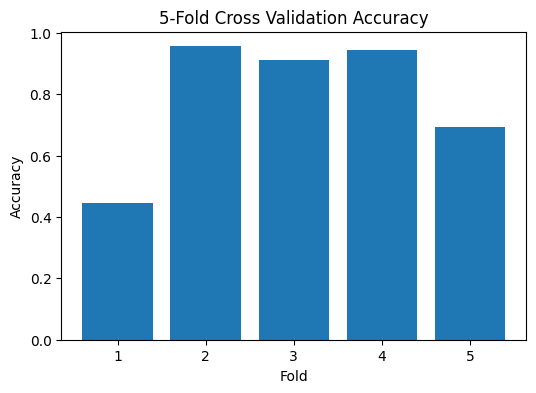

In [437]:
plt.figure(figsize=(6,4))
plt.bar(range(1, 6), cv_scores)
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("5-Fold Cross Validation Accuracy")
plt.show()

Ensemble Learning

Import VotingClassifier

Create Base Models

Build the Voting Classifier

Train the Ensemble

Predict

Evaluate

Compare All Models

In [438]:
#Import VotingClassifier
from sklearn.ensemble import VotingClassifier

In [439]:
voting_model = VotingClassifier(
    estimators=[
        ("rf", models["Random Forest"]),
        ("xgb", models["XGBoost"]),
        ("lgb", models["LightGBM"])
    ],
    voting="soft"
)

In [440]:
rf = RandomForestClassifier(random_state=42)

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

lgb = LGBMClassifier(random_state=42)

voting_model = VotingClassifier(
    estimators=[
        ("rf", rf),
        ("xgb", xgb),
        ("lgb", lgb)
    ],
    voting="soft"
)

In [441]:
voting_model.fit(X_train, y_train)

y_pred = voting_model.predict(X_test)
y_prob = voting_model.predict_proba(X_test)[:, 1]

[LightGBM] [Info] Number of positive: 562, number of negative: 172
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000133 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 936
[LightGBM] [Info] Number of data points in the train set: 734, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.765668 -> initscore=1.184007
[LightGBM] [Info] Start training from score 1.184007
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [442]:
rf = RandomForestClassifier(random_state=42)

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

lgb = LGBMClassifier(random_state=42)

In [443]:
#Train the Ensemble
voting_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 562, number of negative: 172
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000137 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 936
[LightGBM] [Info] Number of data points in the train set: 734, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.765668 -> initscore=1.184007
[LightGBM] [Info] Start training from score 1.184007
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

VotingClassifier(estimators=[('rf', RandomForestClassifier(random_state=42)),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=True,
                                            eval_metric='logloss',
                                            feature_types=None,
                                            feature_weights=None, gamma=None,
                                            grow_p...
                                            interaction_constraints=None,
                                            learning_rate=None, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=None,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=None, n_jobs=None,
                                            num_parallel_tree=None, ...)),
                             ('lgb', LGBMClassifier(random_state=42))],
                 voting='soft')

In [444]:
#Predict
y_pred = voting_model.predict(X_test)

y_prob = voting_model.predict_proba(X_test)[:,1]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [445]:
#Evaluate
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.8967391304347826
Precision: 0.9485294117647058
Recall   : 0.9148936170212766
F1 Score : 0.9314079422382672
ROC AUC  : 0.9371598218703611


In [446]:
#Compare All Models
results_df.loc[len(results_df)] = [
    "Voting Classifier",
    accuracy_score(y_test, y_pred),
    precision_score(y_test, y_pred),
    recall_score(y_test, y_pred),
    f1_score(y_test, y_pred),
    roc_auc_score(y_test, y_prob)
]

results_df.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
7,Voting Classifier,0.896739,0.948529,0.914894,0.931408,0.937160
4,KNN,0.896739,0.923611,0.943262,0.933333,0.888174
2,Random Forest,0.891304,0.929078,0.929078,0.929078,0.937325
6,LightGBM,0.885870,0.941176,0.907801,0.924188,0.936665
0,Logistic Regression,0.880435,0.904762,0.943262,0.923611,0.885865
3,SVM,0.880435,0.904762,0.943262,0.923611,0.860465
5,XGBoost,0.880435,0.940741,0.900709,0.920290,0.929903
1,Decision Tree,0.864130,0.914286,0.907801,0.911032,0.814366


Model Evaluation

Import Libraries

Confusion Matrix

Plot Confusion Matrix

Classification Report

ROC Curve

In [447]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

In [448]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 36   7]
 [ 12 129]]


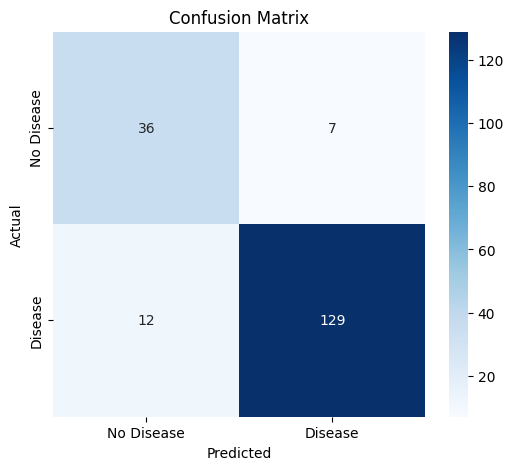

In [449]:
#Plot Confusion Matrix
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Disease','Disease'],
    yticklabels=['No Disease','Disease']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [450]:
#Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.84      0.79        43
           1       0.95      0.91      0.93       141

    accuracy                           0.90       184
   macro avg       0.85      0.88      0.86       184
weighted avg       0.90      0.90      0.90       184



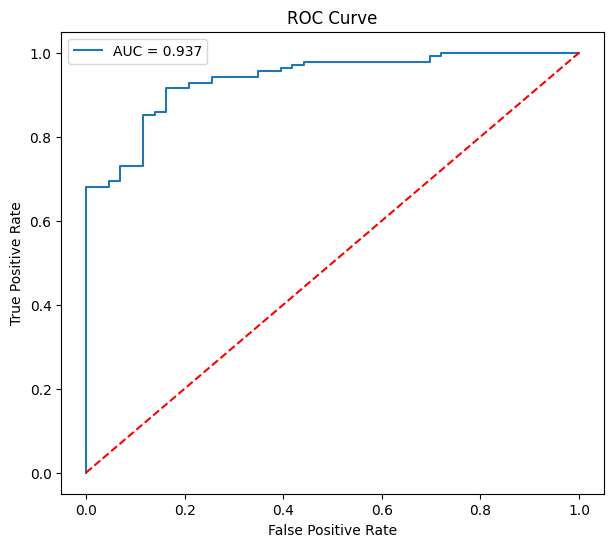

In [451]:
#ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

Explainable AI using SHAP

Install SHAP

Import Libraries

Create SHAP Explainer

Calculate SHAP Values

SHAP Summary Plot

Feature Importance Plot

Explain One Patient

In [452]:
#Install SHAP
!pip install shap

In [453]:
#Import Libraries
import shap

In [454]:
#Create SHAP Explainer
explainer = shap.TreeExplainer(best_model)

In [455]:
print(type(X_test))

<class 'numpy.ndarray'>


In [456]:
X_test_df = pd.DataFrame(X_test, columns=X.columns)

In [457]:
X_test_df = X_test

In [458]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer(X_test_df)

In [459]:
shap_values = explainer.shap_values(X_test_df)

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [460]:
print(type(X_test))

<class 'numpy.ndarray'>


In [461]:
print(type(best_model))

<class 'lightgbm.sklearn.LGBMClassifier'>


In [462]:
shap_values = explainer.shap_values(X_test_df)

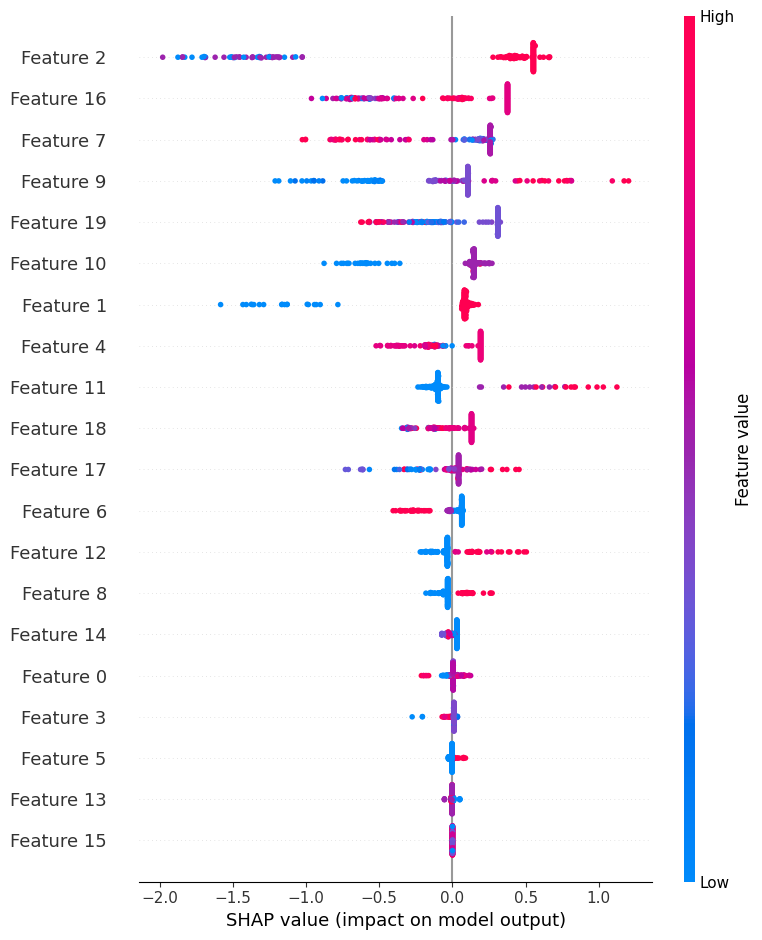

In [463]:
shap.summary_plot(shap_values, X_test_df)

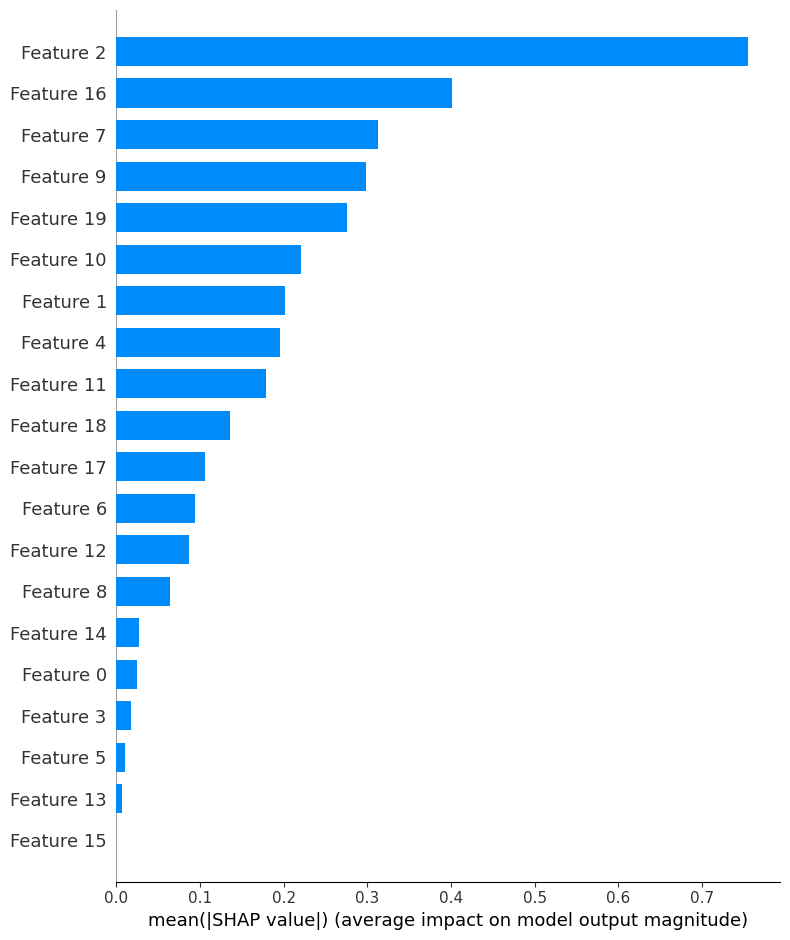

In [464]:
shap.summary_plot(
    shap_values,
    X_test_df,
    plot_type="bar"
)

In [465]:
X_test_df = pd.DataFrame(X_test, columns=X.columns)

In [466]:
print(type(X_test_df))

<class 'pandas.core.frame.DataFrame'>


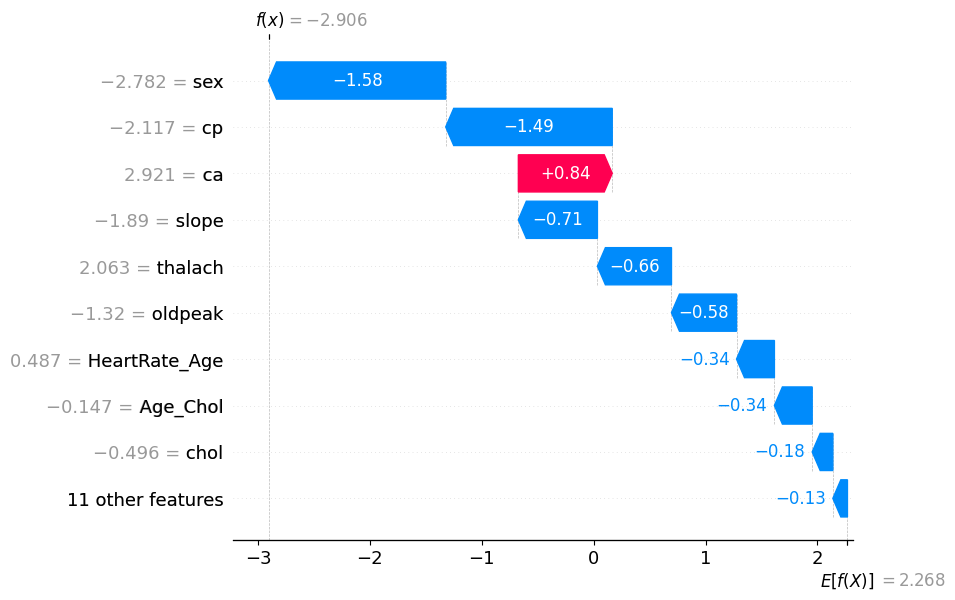

In [467]:
explainer = shap.TreeExplainer(best_model)

shap_values = explainer(X_test_df)

shap.plots.waterfall(shap_values[0])

In [468]:
explainer = shap.TreeExplainer(best_model)

shap_values = explainer.shap_values(X_test_df)

shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test_df.iloc[0]
)

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [469]:
plt.savefig("shap_summary.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

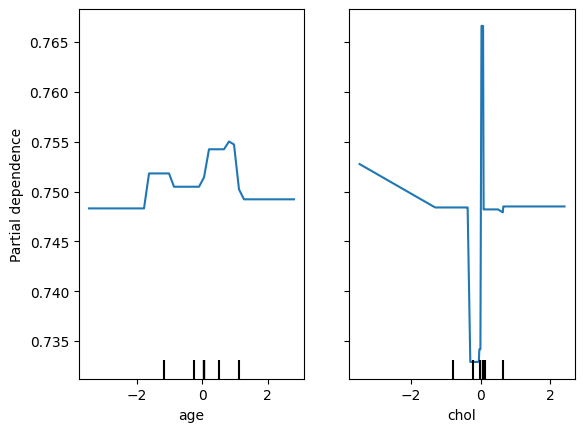

In [470]:
from sklearn.inspection import PartialDependenceDisplay

PartialDependenceDisplay.from_estimator(
    best_model,
    X_test_df,
    ["age", "chol"]
)

plt.show()

In [471]:
joblib.dump(best_model, "heart_disease_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

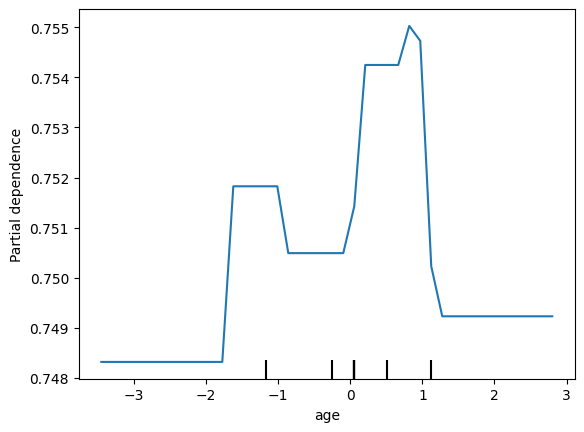

In [472]:
PartialDependenceDisplay.from_estimator(
    best_model,
    X_test_df,
    ["age"]
)

plt.show()

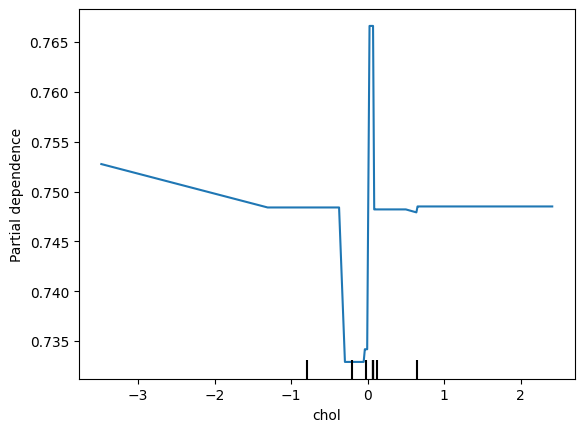

In [473]:
PartialDependenceDisplay.from_estimator(
    best_model,
    X_test_df,
    ["chol"]
)

plt.show()

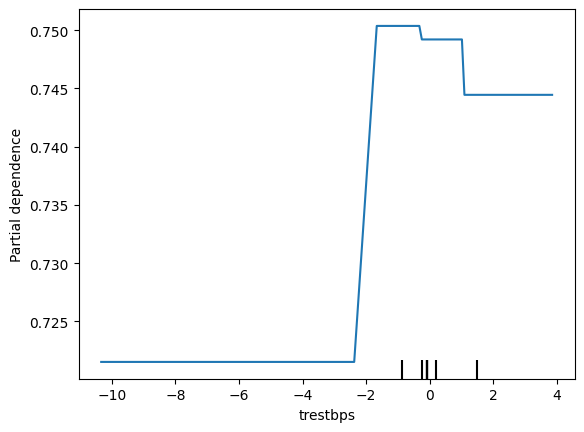

In [474]:
PartialDependenceDisplay.from_estimator(
    best_model,
    X_test_df,
    ["trestbps"]
)

plt.show()

In [475]:
joblib.dump(best_model, "heart_disease_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [476]:
from google.colab import files

files.download("heart_disease_model.pkl")
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [477]:
pip install streamlit

In [478]:
print(X.columns.tolist())

['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'Age_Group', 'Chol_Category', 'BP_Category', 'Age_Chol', 'Age_BP', 'Chol_BP', 'HeartRate_Age']


In [479]:
joblib.dump(best_model, "heart_disease_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [480]:
import os

print(os.listdir())

['.config', 'model_comparison.csv', 'processed.va.data', 'eda_correlation_heatmap.png', 'merged_heart_disease.csv', 'cleveland_raw.csv', 'heart_disease_feature_engineered.csv', 'heart_disease_model.pkl', 'heart_disease_merged.csv', 'processed.hungarian.data', 'feature_importance.png', 'scaler.pkl', 'shap_summary.png', 'drive', 'heart_disease_cleaned.csv', 'processed.switzerland.data', 'best_model.pkl', 'eda_target_distribution.png', 'sample_data']


In [481]:
print("Model size:", os.path.getsize("heart_disease_model.pkl"))
print("Scaler size:", os.path.getsize("scaler.pkl"))

Model size: 91060
Scaler size: 1527


In [482]:
from google.colab import files

files.download("heart_disease_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [483]:
from google.colab import files

files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>